# Step 3: 성별 분리 모델 실험

거세 / 수 / 암 각각 별도 모델을 학습해서 통합 모델과 Macro-F1을 비교합니다.

**실험 흐름**
1. 성별별 데이터 분리 및 분포 확인
2. 성별별 모델 학습
3. 통합 모델 vs 분리 모델 Macro-F1 비교
4. 성별별 변수 중요도 비교

## 0. 라이브러리 & 데이터 로드

> Step 2에서 피처 추가까지 완료된 `train` 데이터프레임을 그대로 사용합니다.
> Step 2 노트북을 먼저 실행한 상태에서 이 노트북을 실행하거나,
> 아래 로드 셀을 실행해서 데이터를 새로 불러오세요.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

pd.set_option('display.max_columns', 100)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ★ 경로를 실제 데이터 위치에 맞게 수정하세요
BASE_DIR = Path(r'C:\Users\Administrator\Desktop\data_mining\hanwoo')

USE_SAMPLE = True
SAMPLE_ROWS = 200_000

train   = pd.read_csv(BASE_DIR / 'hanwoo_train.csv',
                      nrows=SAMPLE_ROWS if USE_SAMPLE else None)
weather = pd.read_csv(BASE_DIR / 'hanwoo_weather.csv')
area    = pd.read_csv(BASE_DIR / 'hanwoo_area.csv')
death   = pd.read_csv(BASE_DIR / 'hanwoo_death.csv')
lineage = pd.read_csv(BASE_DIR / 'hanwoo_lineage.csv',
                      nrows=SAMPLE_ROWS if USE_SAMPLE else None)

# 컬럼명 소문자 통일
for df in [train, weather, area, death, lineage]:
    df.columns = df.columns.str.lower()

# -99 결측치 처리
for df in [train, weather, area, death, lineage]:
    df.replace(-99, np.nan, inplace=True)
    df.replace('-99', np.nan, inplace=True)

# 날짜 변환
train['abatt_date'] = pd.to_datetime(train['abatt_date'], errors='coerce')
train['judge_date'] = pd.to_datetime(train['judge_date'], errors='coerce')
train['birth_ymd']  = pd.to_datetime(train['birth_ymd'].astype(str), format='%Y%m%d', errors='coerce')
weather['date']     = pd.to_datetime(weather['date'], errors='coerce')

# 파생변수
train['abatt_month']  = train['abatt_date'].dt.month
train['judge_delay']  = (train['judge_date'] - train['abatt_date']).dt.days
train['rearing_days'] = (train['abatt_date'] - train['birth_ymd']).dt.days
season_map = {12:'winter',1:'winter',2:'winter',3:'spring',4:'spring',5:'spring',
               6:'summer',7:'summer',8:'summer',9:'fall',10:'fall',11:'fall'}
train['abatt_season'] = train['abatt_month'].map(season_map)

# 농장 규모 피처
area.columns = area.columns.str.lower()
cnt_cols = [c for c in ['c2023','c2024','c2025'] if c in area.columns]
area['farm_avg_cattle'] = area[cnt_cols].mean(axis=1)
latest_cnt = cnt_cols[-1]
area['farm_area_per_cattle'] = area['area'] / (area[latest_cnt] + 1)
area_feat = area[['farm_unique_no', latest_cnt, 'farm_avg_cattle', 'area', 'farm_area_per_cattle']].copy()
train = train.merge(area_feat, on='farm_unique_no', how='left')

# 폐사 피처
death.columns = death.columns.str.lower()
death_cnt = death.groupby('farm_unique_no').size().reset_index(name='farm_death_count')
disease_keywords = ['질병', '병', '질환']
death['is_disease'] = death['dead_reason'].str.contains('|'.join(disease_keywords), na=False).astype(int)
death_disease = death.groupby('farm_unique_no')['is_disease'].mean().reset_index(name='farm_disease_death_ratio')
death_feat = death_cnt.merge(death_disease, on='farm_unique_no', how='left')
train = train.merge(death_feat, on='farm_unique_no', how='left')
train['farm_death_count'] = train['farm_death_count'].fillna(0)

# 혈통 피처
lineage.columns = lineage.columns.str.lower()
lineage['has_father'] = lineage['father_cattle_no'].notna().astype(int)
lineage['has_mother'] = lineage['mother_animal_no'].notna().astype(int)
grandparent_cols = [c for c in lineage.columns if any(x in c for x in ['gmother','gfather'])]
lineage['lineage_depth'] = lineage[grandparent_cols].notna().sum(axis=1) if grandparent_cols else lineage['has_father'] + lineage['has_mother']
lineage_feat = lineage[['cattle_no','has_father','has_mother','lineage_depth']].copy()
train = train.merge(lineage_feat, on='cattle_no', how='left')

print('데이터 로드 및 전처리 완료:', train.shape)
print('성별 분포:')
print(train['judge_sex'].value_counts())

데이터 로드 및 전처리 완료: (223148, 36)
성별 분포:
judge_sex
거세    113109
암     108622
수       1417
Name: count, dtype: int64


## 1. 성별별 데이터 분리 및 분포 확인

In [4]:
# 성별 값 확인
sex_values = train['judge_sex'].unique()
print('성별 고유값:', sex_values)

# 성별별 샘플 수
print('\n성별별 샘플 수:')
print(train['judge_sex'].value_counts())

성별 고유값: ['암' '거세' '수']

성별별 샘플 수:
judge_sex
거세    113109
암     108622
수       1417
Name: count, dtype: int64


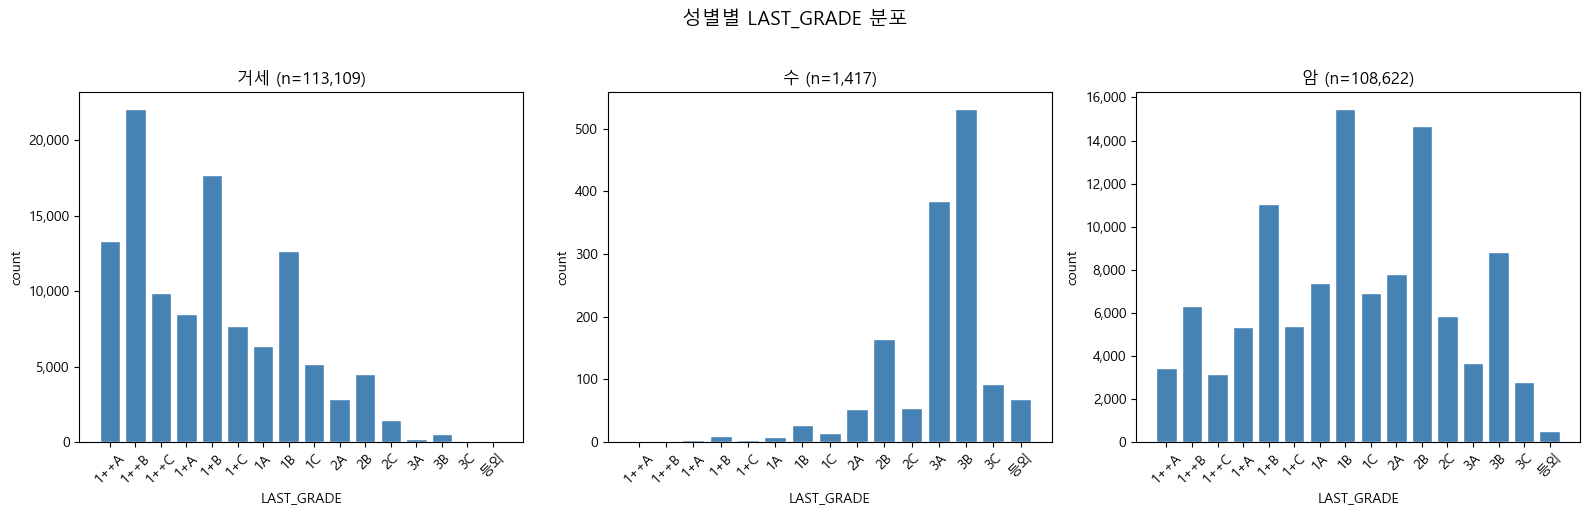

In [5]:
# ★ 실제 성별 값에 맞게 수정하세요 (예: '거세', '수', '암' 또는 'M', 'F', 'C' 등)
SEX_MAP = {
    '거세': '거세',
    '수':   '수',
    '암':   '암'
}

# 성별별 LAST_GRADE 분포 시각화
fig, axes = plt.subplots(1, len(SEX_MAP), figsize=(16, 5), sharey=False)

for ax, (sex_name, sex_val) in zip(axes, SEX_MAP.items()):
    subset = train[train['judge_sex'] == sex_val]['last_grade'].value_counts().sort_index()
    ax.bar(subset.index, subset.values, color='steelblue', edgecolor='white')
    ax.set_title(f'{sex_name} (n={len(train[train["judge_sex"]==sex_val]):,})', fontsize=12)
    ax.set_xlabel('LAST_GRADE')
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('성별별 LAST_GRADE 분포', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. 피처 정의

In [6]:
target = 'last_grade'

numeric_features = [
    'weight','backfat','rea','windex','insfat',
    'yuksak','fatsak','tissue','growth','cost_amt',
    'age','abatt_month','judge_delay','rearing_days',
    'farm_avg_cattle','area','farm_area_per_cattle',
    'farm_death_count','farm_disease_death_ratio',
    'has_father','has_mother','lineage_depth'
]
# judge_sex는 분리 모델에서 제외 (모든 행이 같은 값이므로)
categorical_features = ['sido','sigungu','wgrade','abatt_season','stn']

numeric_features     = [c for c in numeric_features     if c in train.columns]
categorical_features = [c for c in categorical_features if c in train.columns]
features = numeric_features + categorical_features

print(f'총 피처 수: {len(features)}개')

총 피처 수: 27개


## 3. 통합 모델 학습 (비교 기준)

In [7]:
def build_pipeline(class_weight='balanced_subsample'):
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='mean'))])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                         ('onehot',  OneHotEncoder(handle_unknown='ignore'))])
    preprocess = ColumnTransformer([
        ('num', num_pipe, numeric_features),
        ('cat', cat_pipe, categorical_features)
    ])
    return Pipeline([
        ('preprocess', preprocess),
        ('model', RandomForestClassifier(
            n_estimators=100, max_depth=18, min_samples_leaf=2,
            random_state=42, n_jobs=-1, class_weight=class_weight
        ))
    ])

model_df = train[features + [target, 'judge_sex']].copy().dropna(subset=[target])
for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

X_all = model_df[features]
y_all = model_df[target]

X_train_all, X_valid_all, y_train_all, y_valid_all, sex_train, sex_valid = train_test_split(
    X_all, y_all, model_df['judge_sex'],
    test_size=0.2, random_state=42, stratify=y_all
)

model_unified = build_pipeline()
model_unified.fit(X_train_all, y_train_all)
y_pred_unified = model_unified.predict(X_valid_all)

f1_unified = f1_score(y_valid_all, y_pred_unified, average='macro')
print(f'★ 통합 모델 Macro-F1: {f1_unified:.4f}')

c:\Users\Administrator\anaconda3\envs\hanwoo_env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['has_father' 'has_mother' 'lineage_depth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
c:\Users\Administrator\anaconda3\envs\hanwoo_env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['has_father' 'has_mother' 'lineage_depth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


★ 통합 모델 Macro-F1: 0.9283


## 4. 성별 분리 모델 학습

In [8]:
sex_models   = {}   # 성별별 모델 저장
sex_f1       = {}   # 성별별 F1 저장
sex_reports  = {}   # 성별별 classification_report 저장

# 검증셋을 성별별로 분리해서 각 모델로 예측
all_preds = pd.Series(index=y_valid_all.index, dtype=object)

for sex_val in model_df['judge_sex'].dropna().unique():
    print(f'\n=== {sex_val} 모델 학습 중 ===')

    # 훈련셋: 해당 성별만
    train_mask = sex_train == sex_val
    X_tr = X_train_all[train_mask]
    y_tr = y_train_all[train_mask]

    # 검증셋: 해당 성별만
    valid_mask = sex_valid == sex_val
    X_val = X_valid_all[valid_mask]
    y_val = y_valid_all[valid_mask]

    print(f'  훈련: {len(X_tr):,}개 | 검증: {len(X_val):,}개')
    print(f'  등급 종류: {sorted(y_tr.unique())}')

    if len(X_tr) < 100:
        print(f'  ⚠️ 샘플 부족으로 스킵')
        continue

    model = build_pipeline()
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_val)
    all_preds[valid_mask] = y_pred

    f1 = f1_score(y_val, y_pred, average='macro')
    sex_models[sex_val]  = model
    sex_f1[sex_val]      = f1
    sex_reports[sex_val] = classification_report(y_val, y_pred, output_dict=True)

    print(f'  Macro-F1: {f1:.4f}')

# 분리 모델 전체 Macro-F1 (모든 성별 예측을 합쳐서 계산)
valid_idx = all_preds.dropna().index
f1_split = f1_score(y_valid_all[valid_idx], all_preds[valid_idx], average='macro')
print(f'\n★ 분리 모델 전체 Macro-F1: {f1_split:.4f}')


=== 암 모델 학습 중 ===
  훈련: 86,834개 | 검증: 21,788개
  등급 종류: ['1++A', '1++B', '1++C', '1+A', '1+B', '1+C', '1A', '1B', '1C', '2A', '2B', '2C', '3A', '3B', '3C', '등외']


c:\Users\Administrator\anaconda3\envs\hanwoo_env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['has_father' 'has_mother' 'lineage_depth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
c:\Users\Administrator\anaconda3\envs\hanwoo_env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['has_father' 'has_mother' 'lineage_depth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


  Macro-F1: 0.9393

=== 거세 모델 학습 중 ===
  훈련: 90,550개 | 검증: 22,559개
  등급 종류: ['1++A', '1++B', '1++C', '1+A', '1+B', '1+C', '1A', '1B', '1C', '2A', '2B', '2C', '3A', '3B', '3C', '등외']


c:\Users\Administrator\anaconda3\envs\hanwoo_env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['has_father' 'has_mother' 'lineage_depth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
c:\Users\Administrator\anaconda3\envs\hanwoo_env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['has_father' 'has_mother' 'lineage_depth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


  Macro-F1: 0.9203

=== 수 모델 학습 중 ===
  훈련: 1,134개 | 검증: 283개
  등급 종류: ['1++A', '1++B', '1+A', '1+B', '1+C', '1A', '1B', '1C', '2A', '2B', '2C', '3A', '3B', '3C', '등외']
  Macro-F1: 0.7551


c:\Users\Administrator\anaconda3\envs\hanwoo_env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['has_father' 'has_mother' 'lineage_depth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
c:\Users\Administrator\anaconda3\envs\hanwoo_env\lib\site-packages\sklearn\impute\_base.py:637: UserWarning: Skipping features without any observed values: ['has_father' 'has_mother' 'lineage_depth']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
c:\Users\Administrator\anaconda3\envs\hanwoo_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\anaconda3\envs\hanwoo_env\lib\site-pa


★ 분리 모델 전체 Macro-F1: 0.9459


## 5. 통합 모델 vs 분리 모델 비교

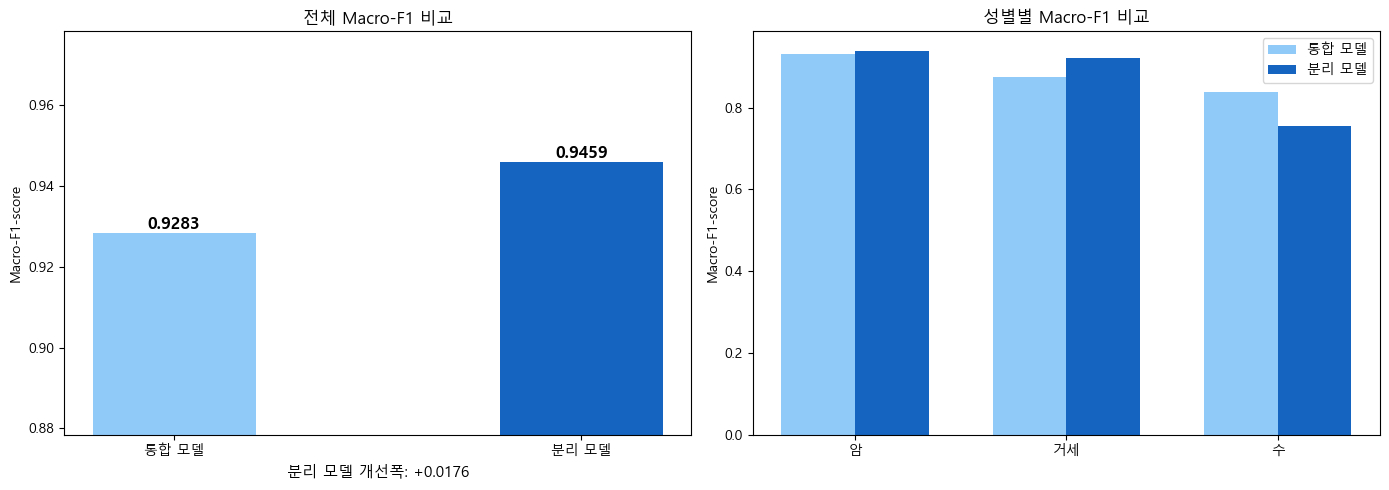


=== 성별별 상세 비교 ===
    통합 모델 F1  분리 모델 F1     개선폭
암     0.9317    0.9393  0.0076
거세    0.8756    0.9203  0.0448
수     0.8383    0.7551 -0.0832

전체 통합 모델: 0.9283
전체 분리 모델: 0.9459
전체 개선폭:    +0.0176


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 Macro-F1 비교
labels = ['통합 모델', '분리 모델']
values = [f1_unified, f1_split]
colors = ['#90CAF9', '#1565C0']
bars = axes[0].bar(labels, values, color=colors, width=0.4)
axes[0].set_ylim(min(values) - 0.05, min(values + [1.0]) + 0.05)
axes[0].set_ylabel('Macro-F1-score')
axes[0].set_title('전체 Macro-F1 비교')
for bar, v in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.001,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')
diff = f1_split - f1_unified
axes[0].set_xlabel(f'분리 모델 개선폭: {diff:+.4f}', fontsize=11)

# 성별별 F1 비교 (통합 vs 분리)
sex_vals = list(sex_f1.keys())
unified_by_sex = {}
for sex_val in sex_vals:
    valid_mask = sex_valid == sex_val
    y_val  = y_valid_all[valid_mask]
    y_pred = y_pred_unified[valid_mask] if hasattr(y_pred_unified, '__len__') else model_unified.predict(X_valid_all[valid_mask])
    unified_by_sex[sex_val] = f1_score(y_val, y_pred, average='macro')

x = np.arange(len(sex_vals))
w = 0.35
axes[1].bar(x - w/2, [unified_by_sex[s] for s in sex_vals], w, label='통합 모델', color='#90CAF9')
axes[1].bar(x + w/2, [sex_f1[s] for s in sex_vals],         w, label='분리 모델', color='#1565C0')
axes[1].set_xticks(x)
axes[1].set_xticklabels(sex_vals)
axes[1].set_ylabel('Macro-F1-score')
axes[1].set_title('성별별 Macro-F1 비교')
axes[1].legend()

plt.tight_layout()
plt.show()

# 요약 테이블
print('\n=== 성별별 상세 비교 ===')
summary = pd.DataFrame({
    '통합 모델 F1': unified_by_sex,
    '분리 모델 F1': sex_f1
})
summary['개선폭'] = summary['분리 모델 F1'] - summary['통합 모델 F1']
summary = summary.round(4)
print(summary)
print(f'\n전체 통합 모델: {f1_unified:.4f}')
print(f'전체 분리 모델: {f1_split:.4f}')
print(f'전체 개선폭:    {diff:+.4f}')

## 6. 성별별 변수 중요도 비교

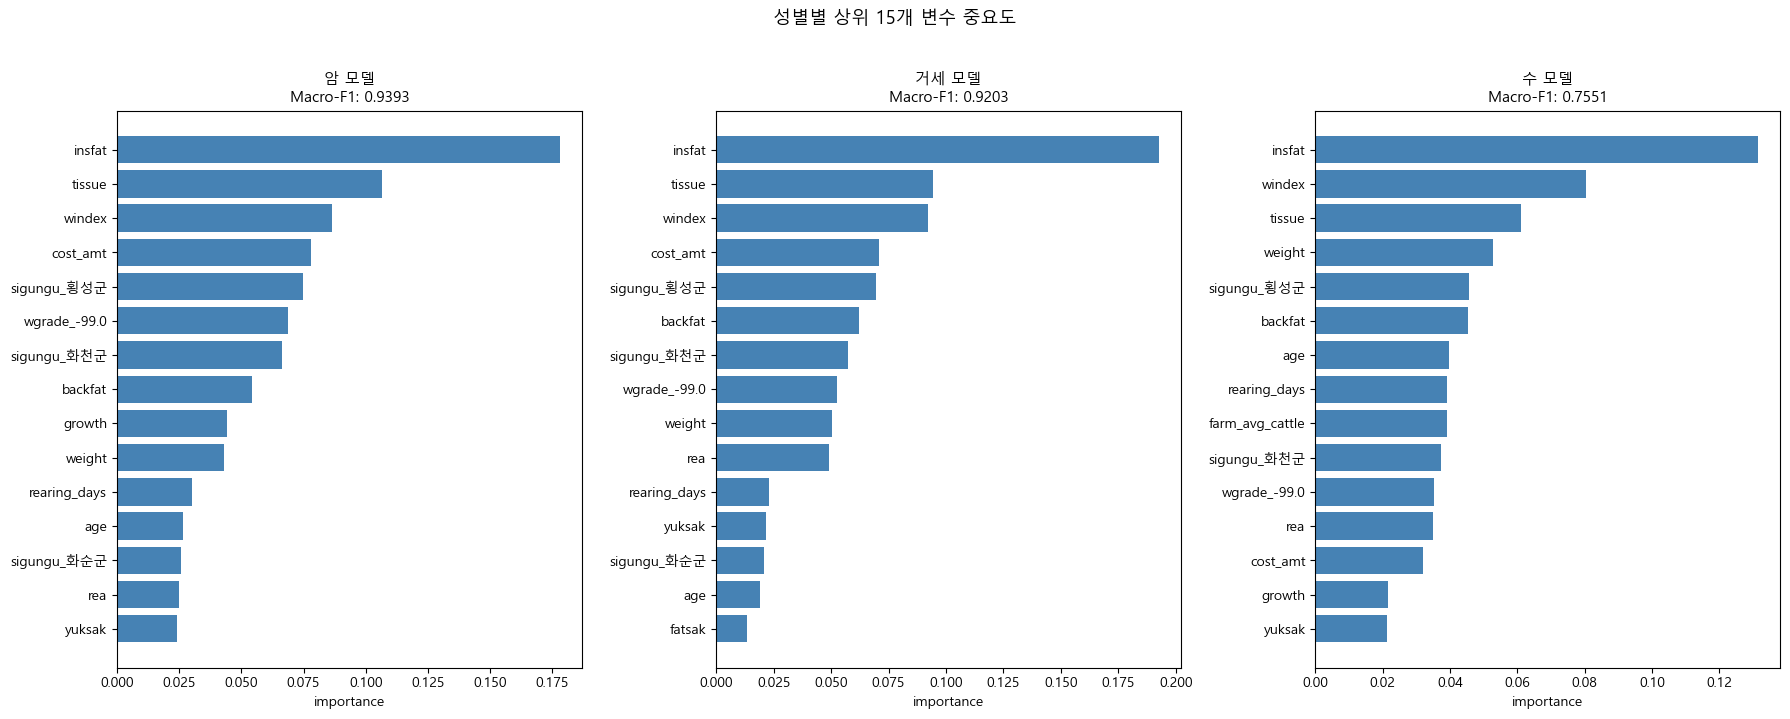

In [10]:
fig, axes = plt.subplots(1, len(sex_models), figsize=(18, 7))
if len(sex_models) == 1:
    axes = [axes]

for ax, (sex_val, model) in zip(axes, sex_models.items()):
    try:
        ohe = model.named_steps['preprocess'].named_transformers_['cat'].named_steps['onehot']
        cat_names = ohe.get_feature_names_out(categorical_features)
        all_names = list(numeric_features) + list(cat_names)
        importances = model.named_steps['model'].feature_importances_
        min_len = min(len(all_names), len(importances))
        feat_imp = pd.DataFrame({
            'feature': all_names[:min_len],
            'importance': importances[:min_len]
        }).sort_values('importance', ascending=False).head(15)

        ax.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1], color='steelblue')
        ax.set_title(f'{sex_val} 모델\nMacro-F1: {sex_f1[sex_val]:.4f}', fontsize=11)
        ax.set_xlabel('importance')
    except Exception as e:
        ax.set_title(f'{sex_val} - 오류: {e}')

plt.suptitle('성별별 상위 15개 변수 중요도', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()